In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# CONSTANTS
G = 6.674e-11
M_earth = 5.9722e24
mu_earth = G * M_earth
R_earth = 6.371e6
ALTITUDE = 400_000

def calculate_initial_conditions(altitude):
    r_orbit = R_earth + altitude
    v_circ = np.sqrt(mu_earth / r_orbit)
    r0 = np.array([r_orbit, 0.0])
    v0 = np.array([0.0, v_circ])
    return r0, v0

In [3]:
r0, v0 = calculate_initial_conditions(ALTITUDE)
print(f"Starting point is {r0}")
print(f"Initial Velocity is {v0}")

Starting point is [6771000.       0.]
Initial Velocity is [   0.         7672.44644817]


In [4]:
def acceleration(r):
    # Satellite mass cancels in F=ma — result independent of satellite mass
    # Dividing by r_mag^3 combines magnitude (GM/r^2) and unit direction
    r_mag = np.linalg.norm(r)
    return -(mu_earth / r_mag**3) * r    # Negative sign: acceleration points towards Earth

In [5]:
test_accel = acceleration(r0)
a_test_mag = (test_accel[0]**2 + test_accel[1]**2)**0.5
print(f"Acceleration vector: {test_accel}")
print(f"Magnitude: {a_test_mag:.4f} m/s²")
print(f"Direction check — should point in -x: {test_accel[0] < 0 and test_accel[1] == 0.0}")

Acceleration vector: [-8.69390555 -0.        ]
Magnitude: 8.6939 m/s²
Direction check — should point in -x: True


In [6]:
# Simulation parameters
num_orbits = 5
dt = 10.0
r_orbit = R_earth + ALTITUDE
T_kepler = 2 * np.pi * np.sqrt(r_orbit**3 / mu_earth)
print(f"Period of an orbit is {T_kepler:.1f} s ({T_kepler/60:.2f} min)")
steps = round((num_orbits * T_kepler) / dt)
print(f"Steps: {steps}")

Period of an orbit is 5545.0 s (92.42 min)
Steps: 2772


In [7]:
def simulate_euler(r0, v0, dt, steps):
    positions = np.zeros((steps, 2))
    velocities = np.zeros((steps, 2))
    r = r0.copy()
    v = v0.copy()
    for i in range(steps):
        positions[i] = r
        velocities[i] = v
        # Calculate acceleration with inline optimized magnitude calculation
        r_mag = (r[0]**2 + r[1]**2)**0.5
        a = -mu_earth / r_mag**3 * r
        r = r + v * dt
        v = v + a * dt
    return positions, velocities

positions, velocities = simulate_euler(r0, v0, dt, steps)
print(positions)

[[ 6771000.                0.        ]
 [ 6771000.            76724.46448172]
 [ 6770130.60944469   153448.92896345]
 ...
 [-7778997.32876515 -6388829.97778824]
 [-7740656.72122145 -6438155.40474702]
 [-7702012.13897765 -6487231.17964984]]


In [8]:
def calculate_orbital_energy(positions, velocities):
    r0_mag = (positions[0][0]**2 + positions[0][1]**2)**0.5
    v0_mag = (velocities[0][0]**2 + velocities[0][1]**2)**0.5
    initial_energy = (v0_mag**2 / 2) - (mu_earth / r0_mag)
    rf_mag = (positions[-1][0]**2 + positions[-1][1]**2)**0.5
    vf_mag = (velocities[-1][0]**2 + velocities[-1][1]**2)**0.5
    final_energy = (vf_mag**2 / 2) - (mu_earth / rf_mag)
    energy_drift_pct = abs((final_energy - initial_energy) / initial_energy) * 100
    return initial_energy, final_energy, energy_drift_pct

initial_energy, final_energy, energy_drift_pct = calculate_orbital_energy(positions, velocities)
print("--- Specific Orbital Energy Check ---")
print(f"Initial Specific Energy: {initial_energy:.2f} J/kg")
print(f"Final Specific Energy:   {final_energy:.2f} J/kg")
print(f"Energy Drift (Euler):    {energy_drift_pct:.4f}%")
print("Note: The 'phantom energy' drift observed is a direct result of the Taylor series truncation error of the Euler method.")

--- Specific Orbital Energy Check ---
Initial Specific Energy: -29433217.25 J/kg
Final Specific Energy:   -20077962.43 J/kg
Energy Drift (Euler):    31.7847%
Note: The 'phantom energy' drift observed is a direct result of the Taylor series truncation error of the Euler method.


In [9]:
def measure_orbital_period(positions, dt):
    # Measures the orbital period from trajectory data by detecting
    # when the satellite completes a full orbit (y crosses zero from
    # negative to positive, i.e. returns to the +x axis).
    # Uses linear interpolation for sub-timestep accuracy.
    crossing_times = []
    for i in range(1, len(positions)):
        y_prev = positions[i - 1, 1]
        y_curr = positions[i, 1]
        # Detect positive-going zero crossing (y goes from - to +)
        if y_prev < 0 and y_curr >= 0:
            # Linear interpolation to find precise crossing time
            frac = -y_prev / (y_curr - y_prev)
            t_cross = (i - 1 + frac) * dt
            crossing_times.append(t_cross)

    if len(crossing_times) < 2:
        print("  Could not measure period (not enough complete orbits).")
        return None, []

    # Period = time between consecutive crossings
    periods = [crossing_times[j] - crossing_times[j - 1]
               for j in range(1, len(crossing_times))]
    avg_period = sum(periods) / len(periods)
    return avg_period, periods

T_measured, all_periods = measure_orbital_period(positions, dt)
print("--- Kepler Period Verification ---")
print(f"Kepler period:    {T_kepler:.1f} s ({T_kepler/60:.2f} min)")
if T_measured is not None:
    period_error_pct = abs(T_measured - T_kepler) / T_kepler * 100
    print(f"Measured period:  {T_measured:.1f} s (avg of {len(all_periods)} orbits)")
    print(f"Period error:     {period_error_pct:.2f}%")
    if len(all_periods) > 1:
        print(f"  Per-orbit periods: {", ".join(f"{p:.1f} s" for p in all_periods)}")


--- Kepler Period Verification ---
Kepler period:    5545.0 s (92.42 min)
Measured period:  7937.0 s (avg of 2 orbits)
Period error:     43.14%
  Per-orbit periods: 7343.9 s, 8530.0 s


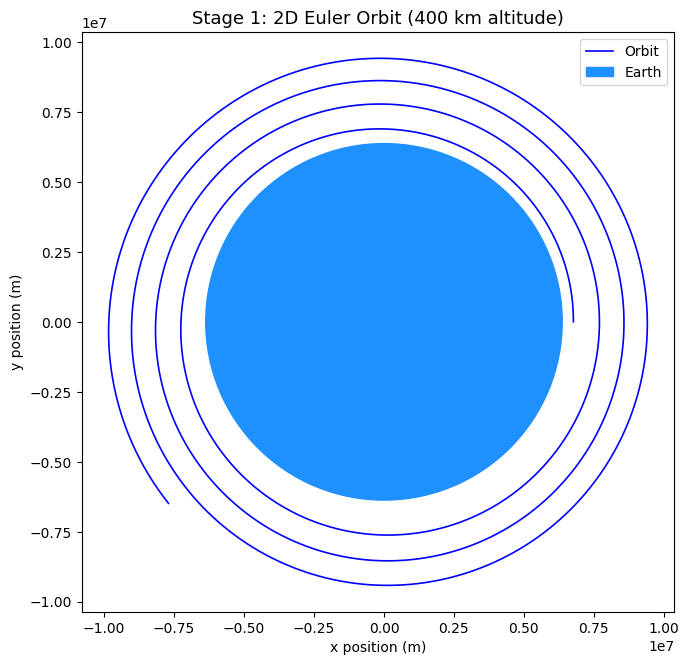

In [10]:
# plot to vizualize Euler
#print(positions[:,0])
x_coords = positions[:, 0]
y_coords = positions[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_coords, y_coords, color="blue", lw=1.2, label="Orbit")

# Earth — Radius 6,371,000m
earth = plt.Circle((0,0), R_earth, color="dodgerblue", label="Earth")
ax.add_patch(earth)

ax.set_aspect("equal")
ax.set_title(f"Stage 1: 2D Euler Orbit ({ALTITUDE/1000:.0f} km altitude)", fontsize=13)
ax.set_xlabel("x position (m)", fontsize=10)
ax.set_ylabel("y position (m)", fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig("../images/stage1_Euler_orbit.png", dpi=150, bbox_inches="tight")
plt.show()

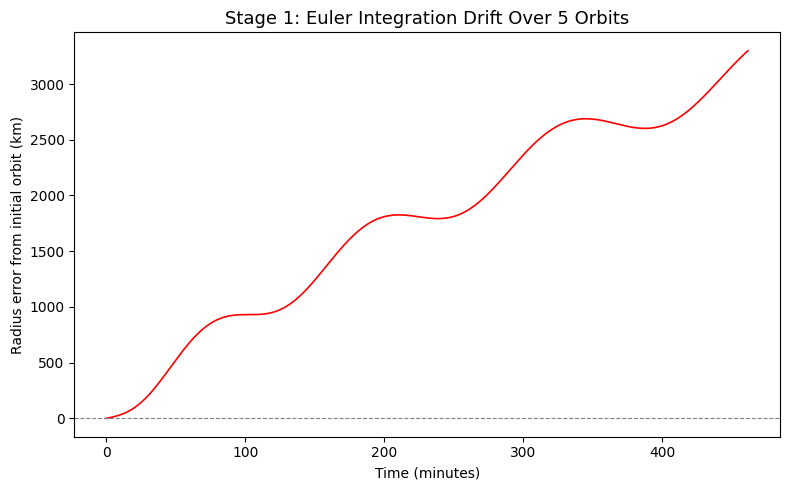

In [11]:
# Visualizing Orbital Drift
radii = np.sqrt(positions[:, 0]**2 + positions[:, 1]**2)
radius_error = radii - radii[0]
time_array = np.arange(steps) * dt / 60

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time_array, radius_error / 1000, color="red", lw=1.2)
ax.set_xlabel("Time (minutes)", fontsize=10)
ax.set_ylabel("Radius error from initial orbit (km)", fontsize=10)
ax.set_title("Stage 1: Euler Integration Drift Over 5 Orbits", fontsize=13)
ax.axhline(0, color="gray", ls="--", lw=0.8)
plt.tight_layout()
plt.savefig("../images/stage1_Euler_drift.png", dpi=150, bbox_inches="tight")
plt.show()